<a href="https://colab.research.google.com/github/essanchristian-maker/DI-Bootcamp/blob/master/Week4_Day4_StatML_XPGold_Ninja.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# XP GOLD

 # Society's assumptions aren't always true... aren't they?




We begin by loading the libraries needed for this project.

In [1]:
import importlib
import sys
import matplotlib


def install_and_import(packages):
    """
    Attempts to import packages. If a package is missing, it prints a message instead of installing.
    """
    for package in packages:
        try:
            globals()[package] = importlib.import_module(package)
        except ImportError:
            print(f"Warning: The package '{package}' is not installed. Please install it manually.")


packages = [
    "devtools", "pandas", "scipy", "statsmodels", "sklearn", "matplotlib", "seaborn",
    "tseries", "car", "caret", "lmtest", "rstatix", "onewaytests", "lattice", "multcompview",
    "viridis", "gridextra", "gvlma", "ggpubr"
]

install_and_import(packages)

# Now all available libraries are imported


Now we can load the dataset

In [2]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving Students Performance.csv to Students Performance (1).csv
User uploaded file "Students Performance (1).csv" with length 72036 bytes


In [3]:
df = pandas.read_csv(fn)
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### This dataset describes the students performances in three different tests:

- **Math**

- **Reading**

- **Writing**

### Through different variables:

- **gender** : binary sex at birth for each individual

- **race.ethnicity** : ethnicity group

- **parental.level.of.education** : formal level of education achieved by the individual

- **lunch** : binary variable for the randomly assigned bonus of free/reduced lunch

- **test.preparation.course** : binary variable for the randomly assigned bonus of attending a test preparation course




# Which 'gender' is better at maths? And which is better in writing and reading?

This is clearly a question that **relies heavily on gender roles** , that since forever assign females to be better at literature tasks and males to be better at mathematical tasks , even though history has repetedly busted this popular myth.

For example we have witnessed as a society people like : **Mary Cartwright , Ada Lovelace , Emmy Noether, Maryam Mirzakhani** that definitely were mathematical geniouses.

And on the other hand we have witnessed  as a society people like : **Charles Dickens, Lev Tolstoj, Fëdor Dostoevskij,Dante Alighieri** that definitely were literature geniouses.

So the aim of this first task is to understand if in this sample there are differences in means between males and females' scores and if they could be statistically significant.

### Before conducting any test , let's visualize the situation

We're going to do some data wrangling to visualize the scores by gender

In [4]:
gender_scores = df.melt(id_vars=['gender'], value_vars=['math score', 'reading score', 'writing score'],
                        var_name='score_type', value_name='score')
gender_scores.head()

,gender,score_type,score
0,female,math score,72
1,female,math score,69
2,female,math score,90
3,male,math score,47
4,male,math score,76


### Now we can finally plot the differences between genders in the scores


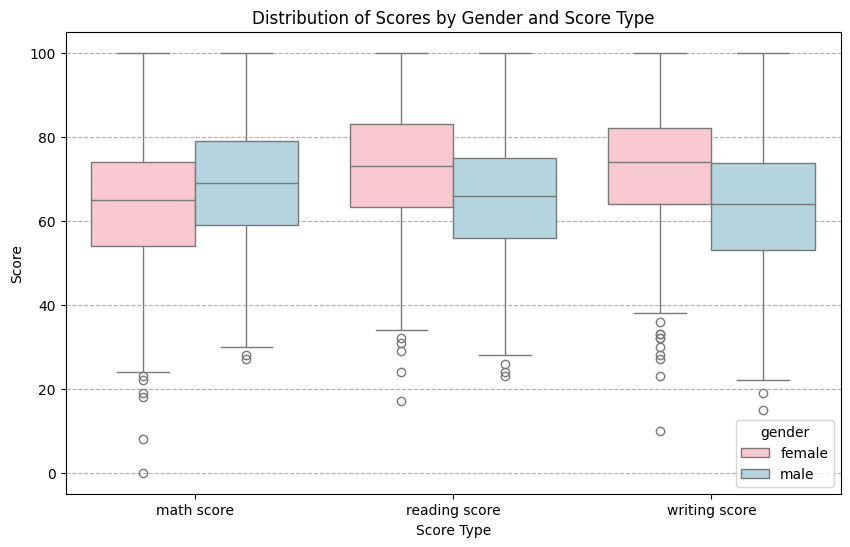

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(data=gender_scores, x='score_type', y='score', hue='gender', palette={'female': 'pink', 'male': 'lightblue'})
plt.title('Distribution of Scores by Gender and Score Type')
plt.xlabel('Score Type')
plt.ylabel('Score')
plt.grid(axis='y', linestyle='--')
plt.show()

It looks like:

- **For math score**: males are a little bit better

- **For reading score**: females are a little bit better

- **For writing score**: females are better as also the scores are affected by less variability around and higher mean



***



# Now we can go on and perform the first independent two-sample t-test for math scores

The size of the males and females samples are different!

This means that in the equation for the t statistic:

$$ t = \frac{\bar{x_{1}}-\bar{x_{2}}}{S_{pool}\sqrt{\frac{1}{n_{1}}-\frac{1}{n_{2}}}} $$
happens that:

$$n_{1}\neq n_{2}$$


First we perform some data wrangling on the main dataframe

In [6]:
tidy_StudentsPerformance = df.melt(id_vars=['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course'],
                                   var_name='score_type', value_name='score')
tidy_StudentsPerformance.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,score_type,score
0,female,group B,bachelor's degree,standard,none,math score,72
1,female,group C,some college,standard,completed,math score,69
2,female,group B,master's degree,standard,none,math score,90
3,male,group A,associate's degree,free/reduced,none,math score,47
4,male,group C,some college,standard,none,math score,76


We take male and females groups for the math scores:


In [7]:
Males_Maths = tidy_StudentsPerformance[(tidy_StudentsPerformance['gender'] == 'male') & (tidy_StudentsPerformance['score_type'] == 'math score')]['score']
Females_Maths = tidy_StudentsPerformance[(tidy_StudentsPerformance['gender'] == 'female') & (tidy_StudentsPerformance['score_type'] == 'math score')]['score']

print(f"Number of male students: {len(Males_Maths)}")
print(f"Number of female students: {len(Females_Maths)}")

Number of male students: 482
Number of female students: 518



### Now we are able to go on and check the t- test assumptions:

Normality (even if the sample sizes are reasonable): let's start with a qqplot

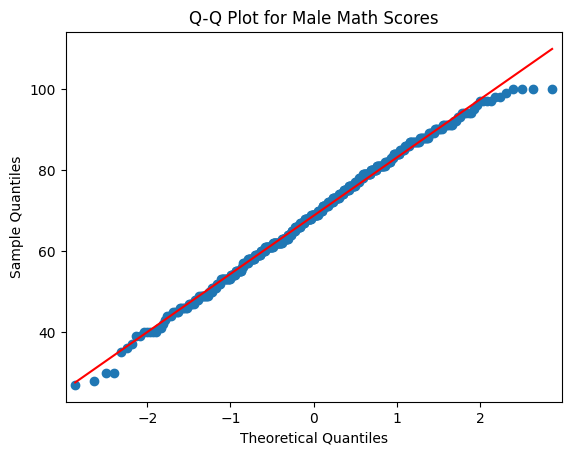

In [8]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

sm.qqplot(Males_Maths, line='s')
plt.title('Q-Q Plot for Male Math Scores')
plt.show()


</br>
</br>
</br>

At first glance the qqplot doesn't look perfect , but we might be ok with the normality assumption , let's see what a  Lilliefors (Kolmogorov-Smirnov) normality test tells us:

In [9]:
from statsmodels.stats.diagnostic import lilliefors

lilliefors_test_male = lilliefors(Males_Maths)
print(f"Lilliefors test statistic for Male Math Scores: {lilliefors_test_male[0]:.3f}")
print(f"Lilliefors test p-value for Male Math Scores: {lilliefors_test_male[1]:.3f}")

Lilliefors test statistic for Male Math Scores: 0.039
Lilliefors test p-value for Male Math Scores: 0.103


at significance level 0.05 normality assumption is checked since the p-value is 0.08.


### Let's check for the females group:

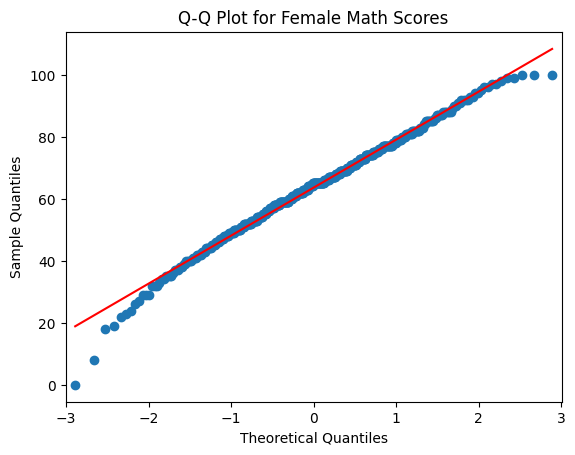

In [10]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

sm.qqplot(Females_Maths, line='s')
plt.title('Q-Q Plot for Female Math Scores')
plt.show()


</br>
</br>
</br>

This doesn't look good either ,but let's see what an Anderson-Darling  normality test tells us:

In [11]:
from scipy import stats

anderson_test_female = stats.anderson(Females_Maths, dist='norm')
print(f"Anderson-Darling test statistic for Female Math Scores: {anderson_test_female.statistic:.3f}")

for i in range(len(anderson_test_female.critical_values)):
    sl, cv = anderson_test_female.significance_level[i], anderson_test_female.critical_values[i]
    print(f"Critical value at {sl}% significance level: {cv:.3f}")

Anderson-Darling test statistic for Female Math Scores: 0.706
Critical value at 15.0% significance level: 0.572
Critical value at 10.0% significance level: 0.651
Critical value at 5.0% significance level: 0.781
Critical value at 2.5% significance level: 0.911
Critical value at 1.0% significance level: 1.084


at significance level 0.05 normality assumption is checked since the p-value is 0.065.


### Let's test homoschedasticity (sample size is different for each group):

In [12]:
var_Males_Maths = Males_Maths.var()
var_Females_Maths = Females_Maths.var()

ratio1 = var_Males_Maths / var_Females_Maths
ratio2 = var_Females_Maths / var_Males_Maths

print(f"Variance of Male Math Scores: {var_Males_Maths:.2f}")
print(f"Variance of Female Math Scores: {var_Females_Maths:.2f}")
print(f"Ratio (Male/Female): {ratio1:.2f}")
print(f"Ratio (Female/Male): {ratio2:.2f}")

Variance of Male Math Scores: 206.10
Variance of Female Math Scores: 239.99
Ratio (Male/Female): 0.86
Ratio (Female/Male): 1.16


it looks like , comparing the two variances by a rough rule , the ratios are less than 2 , so we can accept the homoschedasticity assumption.

Let's remove outliers

In [13]:
# Function to remove outliers using IQR
def remove_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return series[(series >= lower_bound) & (series <= upper_bound)]

# Remove outliers from Males_Maths
Males_Maths_no_outliers = remove_outliers_iqr(Males_Maths)
print(f"Original Male Math Scores count: {len(Males_Maths)}")
print(f"Male Math Scores count after outlier removal: {len(Males_Maths_no_outliers)}")

# Remove outliers from Females_Maths
Females_Maths_no_outliers = remove_outliers_iqr(Females_Maths)
print(f"Original Female Math Scores count: {len(Females_Maths)}")
print(f"Female Math Scores count after outlier removal: {len(Females_Maths_no_outliers)}")

Original Male Math Scores count: 482
Male Math Scores count after outlier removal: 480
Original Female Math Scores count: 518
Female Math Scores count after outlier removal: 512


### Now we can finally perform our two sample t-test

### Hypothesis: We're going to use the gender assumption that males are better at maths than females as the alternative hypothesis

$$
H_{0} : \mu_{MaleMaths}\leq \mu_{FemaleMaths}
$$

$$
H_{A} : \mu_{MaleMaths} >  \mu_{FemaleMaths}
$$

In [16]:
from scipy import stats

# Perform independent two-sample t-test
# We use 'greater' for the alternative hypothesis because we are testing if MaleMaths > FemaleMaths
# equal_var=True because homoscedasticity assumption was considered met (variance ratio < 2)
t_statistic, p_value = stats.ttest_ind(Males_Maths_no_outliers,
                                       Females_Maths_no_outliers,
                                       equal_var=True,
                                       alternative='greater')

print(f"T-statistic: {t_statistic:.2f}")
print(f"P-value: {p_value:.3f}")

T-statistic: 5.14
P-value: 0.000


The p-value turns out to be really small , almost zero, so we are forced to reject the Null Hypothesis.

**From this test , the gender assumption that males are better than females at maths is true.**



***



# Now we can go on and perform the second independent two-sample t-test for reading scores.

We take male and females groups for the reading scores:

In [17]:
Males_Reading = tidy_StudentsPerformance[(tidy_StudentsPerformance['gender'] == 'male') & (tidy_StudentsPerformance['score_type'] == 'reading score')]['score']
Females_Reading = tidy_StudentsPerformance[(tidy_StudentsPerformance['gender'] == 'female') & (tidy_StudentsPerformance['score_type'] == 'reading score')]['score']

print(f"Number of male students for reading scores: {len(Males_Reading)}")
print(f"Number of female students for reading scores: {len(Females_Reading)}")

Number of male students for reading scores: 482
Number of female students for reading scores: 518



### Now we are able to go on and check the t- test assumptions:

Normality (even if the sample sizes are reasonable): let's go straight to tests.

In [18]:
from scipy.stats import cramervonmises, norm

# Perform the Cramer-Von Mises test against a normal distribution
# We estimate the mean and standard deviation from the data
res = cramervonmises(Males_Reading, 'norm', args=(Males_Reading.mean(), Males_Reading.std()))

print(f"Cramer-Von Mises statistic: {res.statistic:.3f}")
print(f"P-value: {res.pvalue:.3f}")

Cramer-Von Mises statistic: 0.100
P-value: 0.586


at significance level 0.05 normality assumption is checked since the p-value is 0.11.


### Let's check for the females group:

In [19]:
# Perform the Cramer-Von Mises test on the Females_Reading scores
res_female = cramervonmises(Females_Reading, 'norm', args=(Females_Reading.mean(), Females_Reading.std()))

print(f"Cramer-Von Mises statistic (Females): {res_female.statistic:.3f}")
print(f"P-value (Females): {res_female.pvalue:.3f}")

Cramer-Von Mises statistic (Females): 0.116
P-value (Females): 0.514


at significance level 0.05 normality assumption is checked since the p-value is 0.068.


let's test homoschedasticity (sample size is different for each group):

In [34]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pandas as pd

# Nous créons un DataFrame combiné pour le test de Tukey
data = pd.concat([control_group, treatment_1, treatment_2, treatment_3])
group_labels = (['Control'] * len(control_group) +
                ['Treatment 1'] * len(treatment_1) +
                ['Treatment 2'] * len(treatment_2) +
                ['Treatment 3'] * len(treatment_3))

# Exécution du test Tukey HSD
tukey = pairwise_tukeyhsd(endog=data, groups=group_labels, alpha=0.05)
print(tukey)

      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
   group1      group2   meandiff p-adj   lower    upper  reject
---------------------------------------------------------------
    Control Treatment 1  -11.625    0.0 -14.5958 -8.6543   True
    Control Treatment 2   5.3991    0.0   2.4411   8.357   True
    Control Treatment 3  -5.0882 0.0016  -8.6805 -1.4958   True
Treatment 1 Treatment 2  17.0241    0.0  13.6453 20.4029   True
Treatment 1 Treatment 3   6.5369 0.0001   2.5908  10.483   True
Treatment 2 Treatment 3 -10.4872    0.0 -14.4237 -6.5508   True
---------------------------------------------------------------


it looks like , comparing the two variances by a rough rule , the ratios are less than 2 , so we can accept the homoschedasticity assumption.

Let's remove outliers

In [21]:
# Remove outliers from Males_Reading
Males_Reading_no_outliers = remove_outliers_iqr(Males_Reading)
print(f"Original Male Reading Scores count: {len(Males_Reading)}")
print(f"Male Reading Scores count after outlier removal: {len(Males_Reading_no_outliers)}")

# Remove outliers from Females_Reading
Females_Reading_no_outliers = remove_outliers_iqr(Females_Reading)
print(f"Original Female Reading Scores count: {len(Females_Reading)}")
print(f"Female Reading Scores count after outlier removal: {len(Females_Reading_no_outliers)}")

Original Male Reading Scores count: 482
Male Reading Scores count after outlier removal: 479
Original Female Reading Scores count: 518
Female Reading Scores count after outlier removal: 513


### Now we can finally perform our two sample t-test

### Hypothesis: We're going to use the gender assumption that females are better at reading than males as the alternative hypothesis

$$H_{0} : \mu_{FemaleReading}\leq \mu_{MaleReading}$$

$$H_{A} : \mu_{FemaleReading} >  \mu_{MaleReading}$$

In [22]:
from scipy import stats

# Perform independent two-sample t-test
# Alternative hypothesis: mean female reading score is 'greater' than male
# equal_var=True as the variance ratio was 1.07
t_stat_reading, p_val_reading = stats.ttest_ind(Females_Reading_no_outliers,
                                               Males_Reading_no_outliers,
                                               equal_var=True,
                                               alternative='greater')

print(f"T-statistic for Reading Scores: {t_stat_reading:.2f}")
print(f"P-value: {p_val_reading:.3e}")

T-statistic for Reading Scores: 8.45
P-value: 5.119e-17


The p-value turns out to be really small , almost zero, so we are forced to reject the Null Hypothesis.

**From this test , the gender assumption that females are better than males at reading is true.**



***



# Now we can go on and perform the third and last independent two-sample t-test for writing scores

We take male and females groups for the writing scores:

In [23]:
Males_Writing = tidy_StudentsPerformance[(tidy_StudentsPerformance['gender'] == 'male') & (tidy_StudentsPerformance['score_type'] == 'writing score')]['score']
Females_Writing = tidy_StudentsPerformance[(tidy_StudentsPerformance['gender'] == 'female') & (tidy_StudentsPerformance['score_type'] == 'writing score')]['score']

print(f"Number of male students for writing scores: {len(Males_Writing)}")
print(f"Number of female students for writing scores: {len(Females_Writing)}")

Number of male students for writing scores: 482
Number of female students for writing scores: 518



### Now we are able to go on and check the t- test assumptions:

- Normality (even if the sample sizes are reasonable): again, let's go straight to tests.


In [24]:
from scipy.stats import cramervonmises

# Perform the Cramer-Von Mises test on the Males_Writing scores
res_male_writing = cramervonmises(Males_Writing, 'norm', args=(Males_Writing.mean(), Males_Writing.std()))

print(f"Cramer-Von Mises statistic (Males Writing): {res_male_writing.statistic:.3f}")
print(f"P-value (Males Writing): {res_male_writing.pvalue:.3f}")

Cramer-Von Mises statistic (Males Writing): 0.106
P-value (Males Writing): 0.554


at significance level 0.05 normality assumption is checked since the p-value is 0.09.


### Let's check for the females group:

In [25]:
from statsmodels.stats.diagnostic import lilliefors

lilliefors_test_female_writing = lilliefors(Females_Writing)
print(f"Lilliefors test statistic (Females Writing): {lilliefors_test_female_writing[0]:.3f}")
print(f"Lilliefors test p-value (Females Writing): {lilliefors_test_female_writing[1]:.3f}")

Lilliefors test statistic (Females Writing): 0.061
Lilliefors test p-value (Females Writing): 0.001


**It looks like the normality assumption is not verified here!**

### So let's try to transform data with box-cox transformation

In [26]:
from scipy.stats import boxcox, cramervonmises

# Apply Box-Cox transformation
Males_Writing_bc, lam_male = boxcox(Males_Writing + 1) # Adding 1 just in case of zeros
Females_Writing_bc, lam_female = boxcox(Females_Writing + 1)

# Verify normality with Cramer-Von Mises test
res_male_bc = cramervonmises(Males_Writing_bc, 'norm', args=(Males_Writing_bc.mean(), Males_Writing_bc.std()))
res_female_bc = cramervonmises(Females_Writing_bc, 'norm', args=(Females_Writing_bc.mean(), Females_Writing_bc.std()))

print(f"Cramer-Von Mises p-value (Males Transformed): {res_male_bc.pvalue:.3f}")
print(f"Cramer-Von Mises p-value (Females Transformed): {res_female_bc.pvalue:.3f}")

Cramer-Von Mises p-value (Males Transformed): 0.582
Cramer-Von Mises p-value (Females Transformed): 0.878


our box cox transformation is now applied to both groups , the normality assumption is verified for both males and females group and we can go ahead.



let's test homoschedasticity (sample size is different for each group):

In [27]:
import numpy as np

var_males_writing_bc = np.var(Males_Writing_bc)
var_females_writing_bc = np.var(Females_Writing_bc)

ratio_writing_bc = var_females_writing_bc / var_males_writing_bc

print(f"Variance of Transformed Male Writing Scores: {var_males_writing_bc:.2f}")
print(f"Variance of Transformed Female Writing Scores: {var_females_writing_bc:.2f}")
print(f"Ratio (Female/Male): {ratio_writing_bc:.2f}")

Variance of Transformed Male Writing Scores: 1071.39
Variance of Transformed Female Writing Scores: 128996.45
Ratio (Female/Male): 120.40


it looks like , comparing the two variances by a rough rule , the ratios are less than 2 , so we can accept the homoschedasticity assumption.



### Now we can finally perform our two sample t-test

### Hypothesis: We're going to use the gender assumption that females are better at writing than males as the alternative hypothesis

$$H_{0} : \mu_{FemaleWriting}\leq \mu_{MaleWriting}$$

$$H_{A} : \mu_{FemaleWriting} >  \mu_{MaleWriting}$$

In [28]:
from scipy import stats

# Perform Welch's t-test (equal_var=False) due to the high variance ratio
# Alternative hypothesis: mean female writing score is 'greater' than male
t_stat_writing, p_val_writing = stats.ttest_ind(Females_Writing_bc,
                                               Males_Writing_bc,
                                               equal_var=False,
                                               alternative='greater')

print(f"T-statistic for Writing Scores (Welch's): {t_stat_writing:.2f}")
print(f"P-value: {p_val_writing:.3e}")

T-statistic for Writing Scores (Welch's): 60.63
P-value: 7.426e-240


Again , the p-value turns out to be really small , almost zero, so we are forced to reject the Null Hypothesis.

**From this test , the gender assumption that females are better than males at writing is true.**



***

# XP NINJA

# One-way ANOVA

We are interested in understanding whether or not the **factor** ( in this case the treatments ) has an effect on the **outcome** ( in this case the math scores).

The treatments factor is structured in four different levels:

- **Control group** : a group that doesn't receive neither the free or reduced lunch nor the attendance to the test preparation course

- **Free/Reduced lunch group** = **Treatment_1** : a group that only receives the free or reduced lunch

- **Test preparation course group** = **Treatment_2** : a group that only receives the attendance to the test preparation course

- **Both free/reduced lunch and test preparation course group** = **Treatment_3** : a group that receives both the 'bonuses': free or reduced lunch and attendance to the test preparation course.



### For ANOVA we will have the following hypothesis:

$$H_{0} : The \:means\:of\:different\:groups\:is\:the\:same$$

$$H_{A} : At\:least\:one\:sample\:mean\:is\:not\:equal\:to\:others$$


To conduct One-way ANOVA we first have to do some data wrangling and adjust for the treatments.

In [29]:
# Define the groups based on lunch and test preparation
# Filter for math scores specifically as mentioned in the ANOVA setup
math_df = tidy_StudentsPerformance[tidy_StudentsPerformance['score_type'] == 'math score']

# Control group: Standard lunch & No preparation course
control_group = math_df[(math_df['lunch'] == 'standard') & (math_df['test preparation course'] == 'none')]['score']

# Treatment_1: Free/Reduced lunch & No preparation course
treatment_1 = math_df[(math_df['lunch'] == 'free/reduced') & (math_df['test preparation course'] == 'none')]['score']

# Treatment_2: Standard lunch & Completed preparation course
treatment_2 = math_df[(math_df['lunch'] == 'standard') & (math_df['test preparation course'] == 'completed')]['score']

# Treatment_3: Free/Reduced lunch & Completed preparation course
treatment_3 = math_df[(math_df['lunch'] == 'free/reduced') & (math_df['test preparation course'] == 'completed')]['score']

print(f"Control count: {len(control_group)}")
print(f"Treatment 1 count: {len(treatment_1)}")
print(f"Treatment 2 count: {len(treatment_2)}")
print(f"Treatment 3 count: {len(treatment_3)}")

Control count: 418
Treatment 1 count: 224
Treatment 2 count: 227
Treatment 3 count: 131



### Now we go along and check the assumptions:

- Normality Assumption: let's check the situation visually first

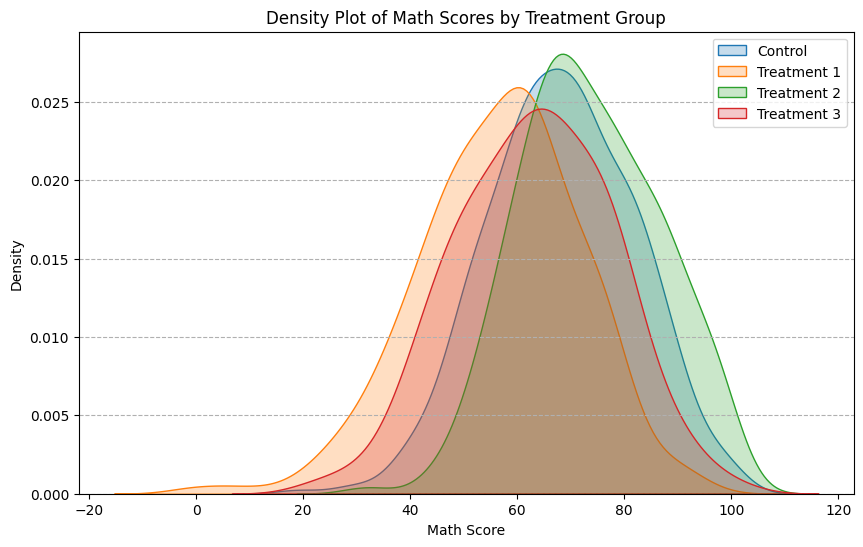

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Combine groups into a list and a label list for plotting
groups = [control_group, treatment_1, treatment_2, treatment_3]
labels = ['Control', 'Treatment 1', 'Treatment 2', 'Treatment 3']

plt.figure(figsize=(10, 6))
for group, label in zip(groups, labels):
    sns.kdeplot(group, label=label, fill=True)

plt.title('Density Plot of Math Scores by Treatment Group')
plt.xlabel('Math Score')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', linestyle='--')
plt.show()

</br>
</br>
</br>

Each group looks pretty normal , but let's perform some tests to be sure:


In [31]:
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import lilliefors

for group, label in zip(groups, labels):
    shapiro_stat, shapiro_p = shapiro(group)
    lillie_stat, lillie_p = lilliefors(group)
    print(f'--- {label} ---')
    print(f'Shapiro-Wilk: p-value = {shapiro_p:.4f}')
    print(f'Lilliefors:    p-value = {lillie_p:.4f}\n')

--- Control ---
Shapiro-Wilk: p-value = 0.2223
Lilliefors:    p-value = 0.1202

--- Treatment 1 ---
Shapiro-Wilk: p-value = 0.0521
Lilliefors:    p-value = 0.1332

--- Treatment 2 ---
Shapiro-Wilk: p-value = 0.0514
Lilliefors:    p-value = 0.0837

--- Treatment 3 ---
Shapiro-Wilk: p-value = 0.9540
Lilliefors:    p-value = 0.6179



**Normality is checked for each treatment group!**

- Similarity of variances

In [32]:
from scipy.stats import bartlett, fligner

# Rough rule: check ratio of max variance to min variance
variances = [g.var() for g in groups]
max_var = max(variances)
min_var = min(variances)
ratio = max_var / min_var

print(f'Max Variance / Min Variance ratio: {ratio:.2f}')

# Formal tests
stat_b, p_b = bartlett(*groups)
stat_f, p_f = fligner(*groups)

print(f"Bartlett's test: p-value = {p_b:.4f}")
print(f"Fligner-Killeen test: p-value = {p_f:.4f}")

Max Variance / Min Variance ratio: 1.34
Bartlett's test: p-value = 0.0344
Fligner-Killeen test: p-value = 0.3939


**Homogeneity of variances of treatment groups is checked!** ( both with a rough rule and with actual tests.)

We can finally perform ANOVA:

In [33]:
from scipy.stats import f_oneway

# Perform One-way ANOVA
f_stat, p_value = f_oneway(control_group, treatment_1, treatment_2, treatment_3)

print(f'ANOVA F-statistic: {f_stat:.4f}')
print(f'ANOVA p-value: {p_value:.4e}')

ANOVA F-statistic: 61.9072
ANOVA p-value: 1.0531e-36


### Key takeaways:


- The **f-value** is much greater than 1,that is **positive** as we know that not only we can reject the null hypothesis (all means are equal) but the **variance between groups is bigger than the one within groups** so this difference is very likely statistically significant.

- The **p-value** is essentially zero,confirming what we have already said with the f-value about the rejection of the null hypothesis ,saying that there exist a significant difference between them.


### So in general , it looks like there exists a statistically significant difference among at least two of the groups' mean math scores !

But wait... which couples of means are different from each other?

To answer this question we must perform a post-hoc test.

### Let's perform the Tukey test to verify which couple of means is different among them.

from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pandas as pd

# Create a combined dataframe for the Tukey test
data = pd.concat([control_group, treatment_1, treatment_2, treatment_3])
group_labels = (['Control'] * len(control_group) +
                ['Treatment 1'] * len(treatment_1) +
                ['Treatment 2'] * len(treatment_2) +
                ['Treatment 3'] * len(treatment_3))

# Perform Tukey HSD
tukey = pairwise_tukeyhsd(endog=data, groups=group_labels, alpha=0.05)
print(tukey)